# Data Exploration

## I. Tổng quan về dữ liệu thô

### 1. Tải thư viện & đọc file

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [2]:
path = "../data/amazon_crawl/amazon_products_US_20260321_231510.csv"
try:
    df = pd.read_csv(path)
    print("[SUCCESS]: Loading dataset successful")
except Exception as e:
    print(f"[ERROR]: Loading dataset fail: {e}")

[SUCCESS]: Loading dataset successful


### 2. Thông tin cơ bản

In [4]:
df.head()

,country_code,asin,title,product_name,brand_info,current_price,original_price,currency,rating,reviews,...,product_details_json,key_features_json,full_description,category_hierarchy_json,variation_dimensions_json,variants_json,all_variants_json,additional_image_urls_json,product_videos_json,top_reviews_json
0,US,B0GR6JMY9W,Apple 2026 MacBook Neo 13-inch Laptop with A18...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,{},[],NaN,[],[],{},{},[],[],[]
1,US,B0947BJ67M,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,{},[],NaN,[],[],{},{},[],[],[]
2,US,B0FWD6SKL6,Apple 2025 MacBook Pro Laptop with M5 chip wit...,Apple 2025 MacBook Pro Laptop with M5 chip wit...,Visit the Apple Store,1399.99,1599.0,USD,4.8,290.0,...,"{""Brand"": ""Apple"", ""Model Name"": ""MacBook Pro""...","[""SUPERCHARGED BY M5 — The 14-inch MacBook Pro...",NaN,[],"[""style"", ""size"", ""color"", ""configuration""]","{""style"": [{""asin"": ""B0FWD6SKL6"", ""value"": ""Ap...","{""B0GR1JBFZJ"": {""style"": ""Apple M5 Pro chip"", ...","[""https://m.media-amazon.com/images/I/6112T6g2...","[{""id"": ""amzn1.vse.video.0ad455fc48364701890b2...","[{""review_id"": ""R1H9MVROAP2XKG"", ""product_asin..."
3,US,B0G4B33S9P,"HP Business Laptop with Microsoft Office 365, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,{},[],NaN,[],[],{},{},[],[],[]
4,US,B0DZDBDCFH,Apple 2025 MacBook Air 15-inch Laptop with M4 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,{},[],NaN,[],[],{},{},[],[],[]


#### 2.1. Kích thước dữ liệu

In [5]:
print(f"Data shape: {df.shape}")

num_rows, num_columns = df.shape
print(f"Amount of rows is: {num_rows}")
print(f"Amount of columns is: {num_columns}")

Data shape: (2754, 73)
Amount of rows is: 2754
Amount of columns is: 73


#### 2.2. Kiểu dữ liệu và ý nghĩa của các đặc trưng

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2754 entries, 0 to 2753
Data columns (total 73 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_code                      2754 non-null   str    
 1   asin                              2754 non-null   str    
 2   title                             2754 non-null   str    
 3   product_name                      376 non-null    str    
 4   brand_info                        374 non-null    str    
 5   current_price                     373 non-null    float64
 6   original_price                    269 non-null    float64
 7   currency                          376 non-null    str    
 8   rating                            374 non-null    float64
 9   reviews                           376 non-null    float64
 10  availability                      362 non-null    str    
 11  is_prime                          376 non-null    object 
 12  is_bestseller    

| STT | Feature | Đơn vị | Ý nghĩa |
|-----|--------|-------|--------|
| 1 | country_code | Không có | Mã quốc gia nơi sản phẩm được liệt kê (ví dụ: US). Dùng để phân biệt dữ liệu theo từng thị trường hoặc khu vực địa lý. |
| 2 | asin | Không có | Mã định danh duy nhất của sản phẩm trên Amazon (Amazon Standard Identification Number). Dùng để phân biệt và truy xuất từng sản phẩm. |
| 3 | title | Không có | Tiêu đề đầy đủ của sản phẩm hiển thị trên Amazon, thường chứa thông tin về thương hiệu và cấu hình. |
| 4 | key_features_count | Số lượng | Số lượng các đặc điểm nổi bật của sản phẩm được liệt kê, phản ánh mức độ mô tả chi tiết. |
| 5 | all_variants_count | Số lượng | Tổng số biến thể của sản phẩm như màu sắc, dung lượng hoặc cấu hình. |
| 6 | link | URL | Đường dẫn đến trang sản phẩm trên Amazon. |
| 7 | image_url | URL | Đường dẫn đến hình ảnh chính của sản phẩm. |
| 8 | search_price | USD ($) | Giá sản phẩm hiển thị trong kết quả tìm kiếm. |
| 9 | search_original_price | USD ($) | Giá gốc của sản phẩm trước khi giảm giá. |
| 10 | search_currency | Không có | Đơn vị tiền tệ của giá sản phẩm (ví dụ: USD). |
| 11 | search_rating | Điểm | Điểm đánh giá trung bình của sản phẩm từ người dùng từ 0 tới 5. |
| 12 | search_reviews | Số lượng | Tổng số lượt đánh giá của sản phẩm. |
| 13 | search_delivery_info | Không có | Thông tin về giao hàng như thời gian và chi phí. |
| 14 | search_sales_volume | Không có | Số lượng sản phẩm đã bán (thường ở dạng text như “1K+ bought”). |
| 15 | search_is_best_seller | Boolean | Cho biết sản phẩm có thuộc danh sách Best Seller hay không. |
| 16 | search_is_amazon_choice | Boolean | Cho biết sản phẩm có được gắn nhãn “Amazon’s Choice” hay không. |
| 17 | search_is_prime | Boolean | Cho biết sản phẩm có hỗ trợ Amazon Prime hay không. |
| 18 | search_is_climate_friendly | Boolean | Cho biết sản phẩm có thân thiện với môi trường hay không. |
| 19 | search_number_of_offers | Số lượng | Số lượng người bán đang cung cấp sản phẩm này. |
| 20 | search_lowest_offer_price | USD ($) | Giá thấp nhất trong các offer hiện có. |
| 21 | search_has_variations | Boolean | Cho biết sản phẩm có nhiều biến thể hay không. |
| 22 | additional_images_count | Số lượng | Số lượng hình ảnh bổ sung của sản phẩm. |
| 23 | product_videos_count | Số lượng | Số lượng video chính thức của sản phẩm. |
| 24 | user_videos_count | Số lượng | Số lượng video do người dùng đăng tải. |
| 25 | category_hierarchy_depth | Cấp độ | Độ sâu của cây phân cấp danh mục sản phẩm. |
| 26 | variation_dimensions_count | Số lượng | Số chiều biến thể của sản phẩm (màu, size, cấu hình...). |
| 27 | frequently_bought_together_count | Số lượng | Số lượng sản phẩm thường được mua cùng với sản phẩm này. |

### 3. Kiểm tra dòng trùng lặp

In [8]:
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

Number of duplicated rows: 89


Có 89 dòng trùng lặp, sẽ tiến hành xóa các dòng trùng lặp này.

### 4. Kiểm tra dữ liệu thiếu

Khi quan sát dữ liệu ban đầu, có thể thấy nhiều cột xuất hiện các giá trị như [], {} hoặc chuỗi rỗng. Điều này có thể làm sai lệch kết quả khi phân tích. Vì vậy, trước tiên cần chuyển các giá trị này về dạng NaN để thống nhất cách biểu diễn dữ liệu thiếu. Sau khi thực hiện bước này, tiến hành kiểm tra tỷ lệ missing của từng feature để hiểu rõ mức độ thiếu dữ liệu.

In [9]:
df = df.replace(["[]", "{}", ""], np.nan)
zero_missing_cols = 0

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    print(f"'{col}': {missing_percentage:.2f}%")
    
    if missing_percentage > 85:
        zero_missing_cols += 1

print(f"Number of columns with more than 85% missing values: {zero_missing_cols}")

'country_code': 0.00%
'asin': 0.00%
'title': 0.00%
'product_name': 86.35%
'brand_info': 86.42%
'current_price': 86.46%
'original_price': 90.23%
'currency': 86.35%
'rating': 86.42%
'reviews': 86.35%
'availability': 86.86%
'is_prime': 86.35%
'is_bestseller': 86.35%
'is_amazon_choice': 86.35%
'sales_volume': 87.62%
'key_features_count': 0.00%
'all_variants_count': 0.00%
'link': 0.00%
'image_url': 0.00%
'search_price': 0.80%
'search_original_price': 48.80%
'search_currency': 0.80%
'search_rating': 0.11%
'search_reviews': 0.00%
'search_delivery_info': 1.38%
'search_sales_volume': 7.04%
'search_is_best_seller': 0.00%
'search_is_amazon_choice': 0.00%
'search_is_prime': 0.00%
'search_is_climate_friendly': 0.00%
'search_number_of_offers': 0.00%
'search_lowest_offer_price': 0.80%
'search_has_variations': 0.00%
'slug': 86.60%
'parent_asin': 89.47%
'landing_asin': 86.35%
'brand_url': 86.42%
'unit_price': 97.49%
'unit_count': 97.49%
'condition': 91.29%
'number_of_offers': 86.35%
'delivery_info': 86

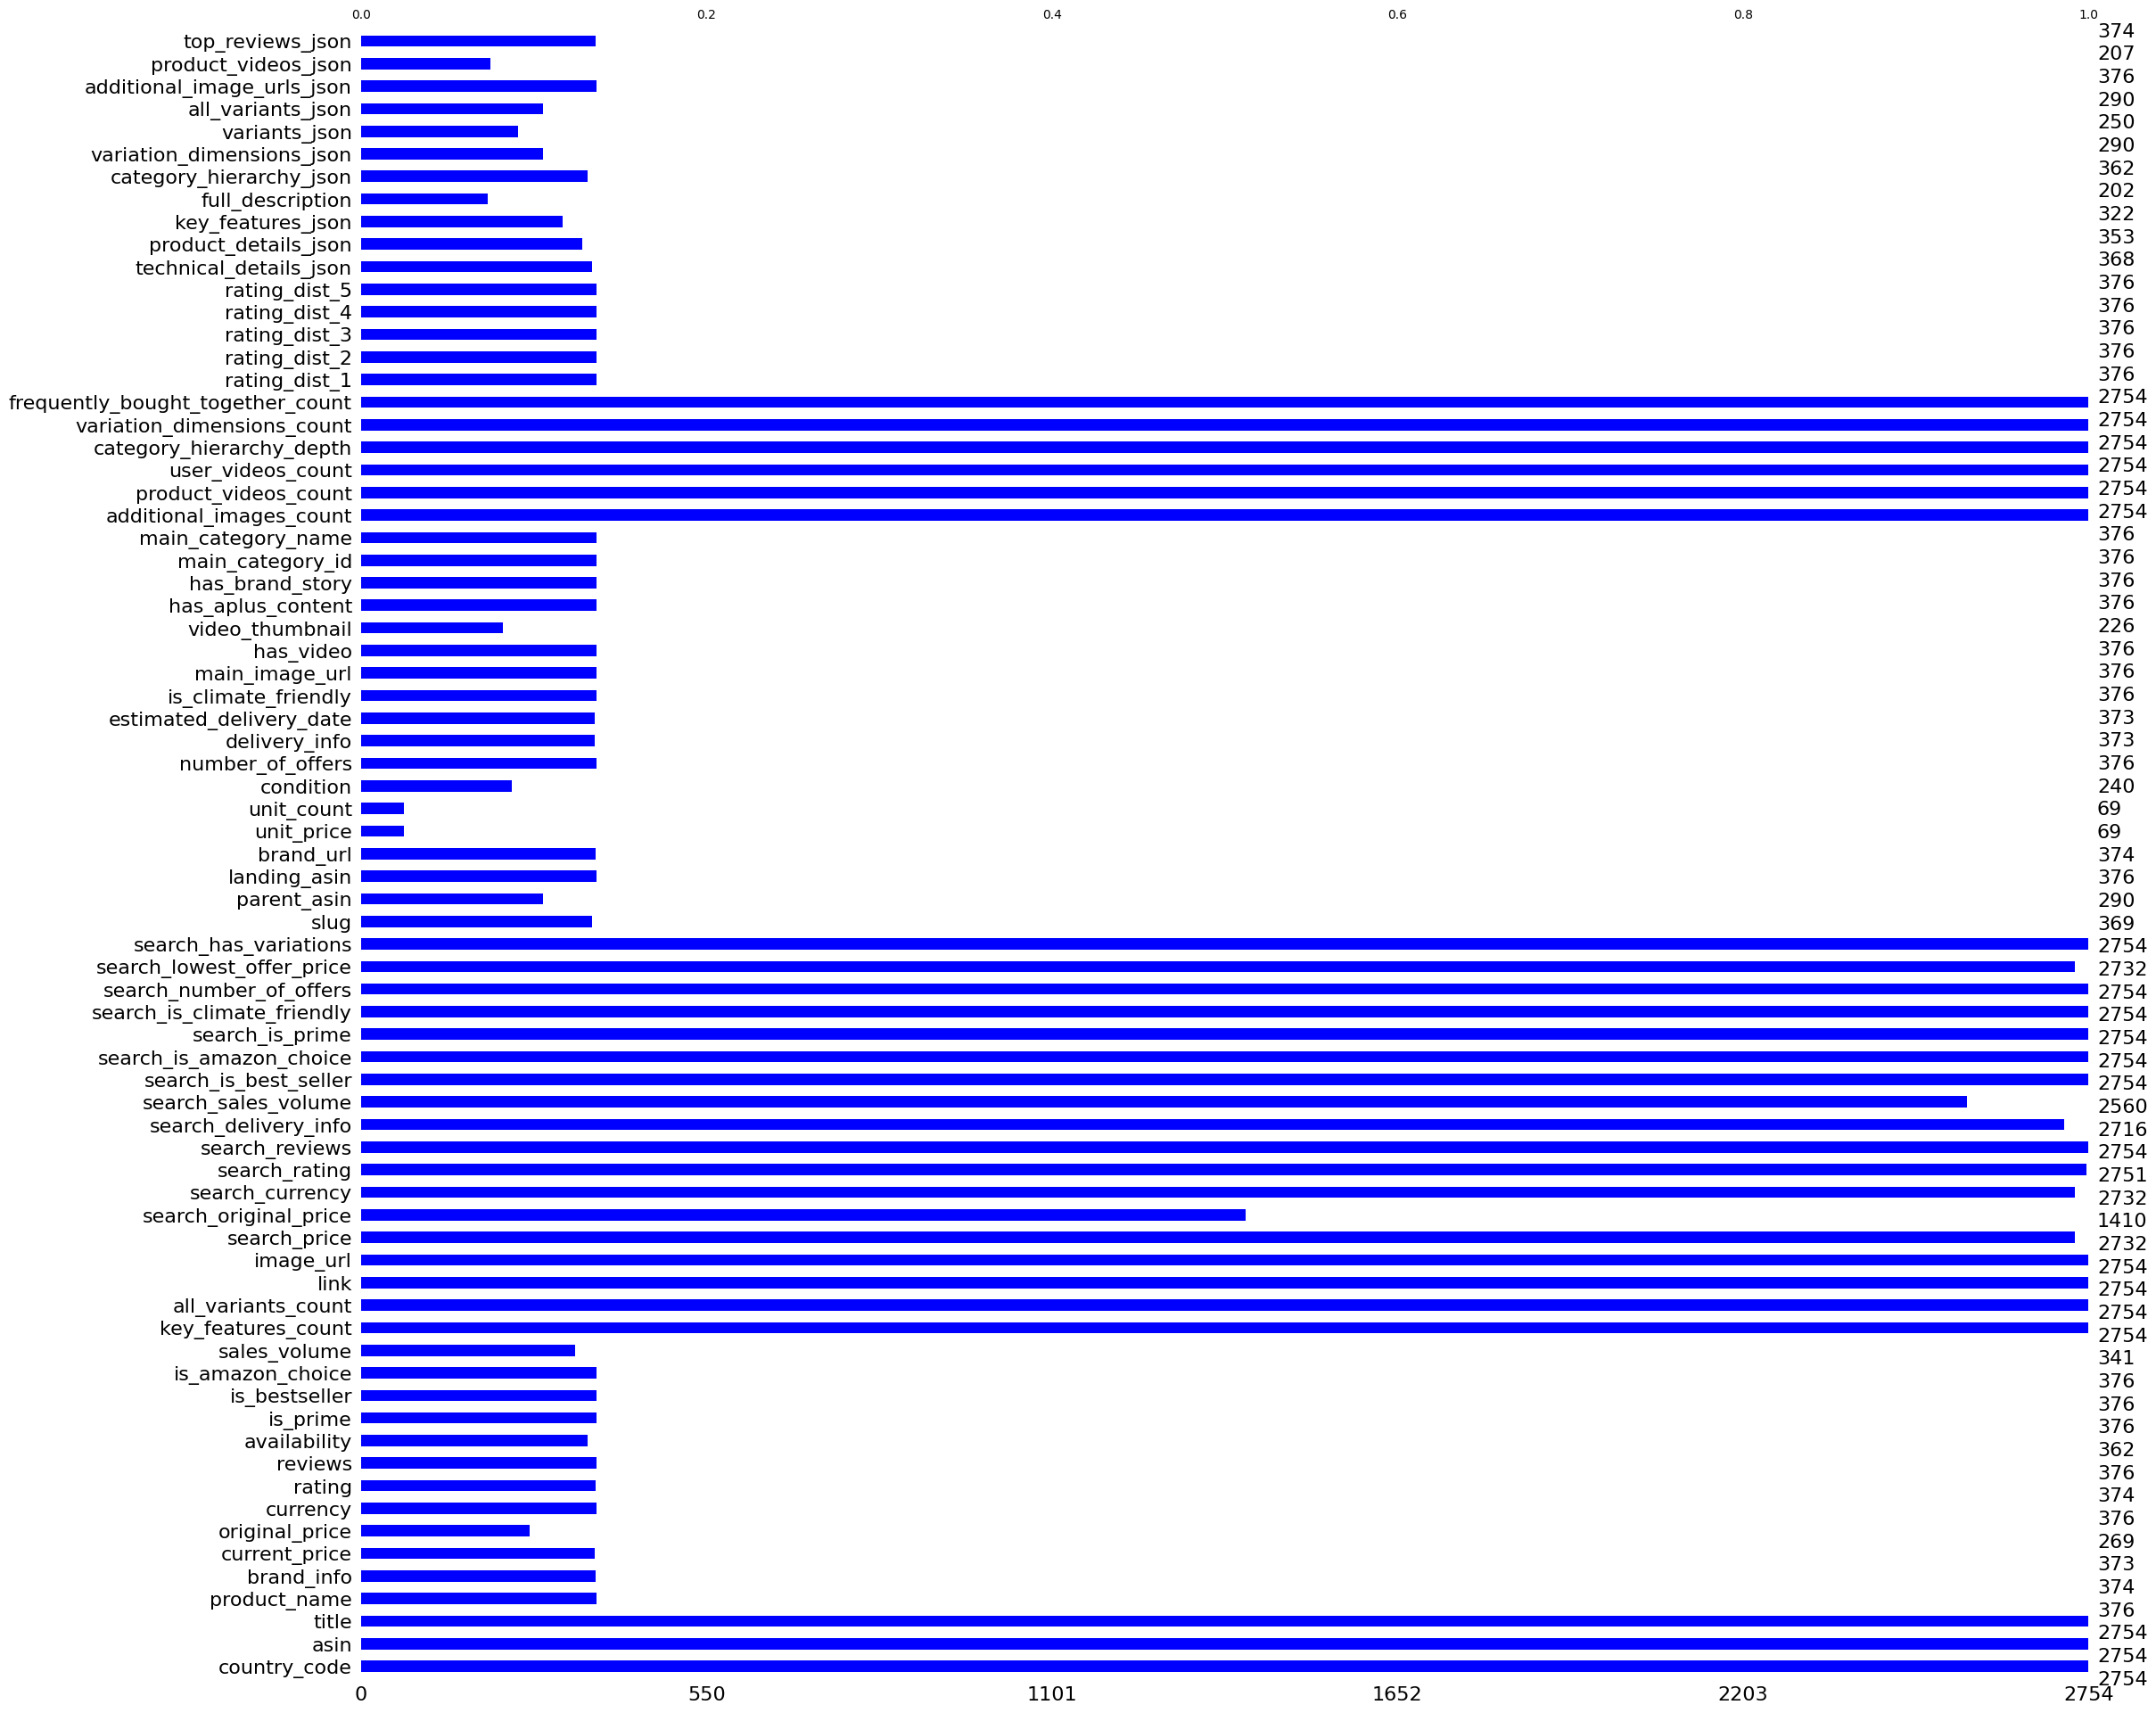

In [10]:
msno.bar(df, color='blue')
plt.show()

Dựa trên kết quả đã phân tích, có tới 46 feature có tỷ lệ missing vượt quá 85%. Với mức độ thiếu dữ liệu quá lớn như vậy, các feature này không còn mang nhiều ý nghĩa trong việc phân tích hay xây dựng mô hình. Do đó, trong bước tiền xử lý dữ liệu, ta sẽ tiến hành loại bỏ các cột này nhằm giảm nhiễu và cải thiện chất lượng dữ liệu đầu vào.

In [11]:
cols_to_drop = []

for col in df.columns:
    missing_percentage = (df[col].isnull().sum() / len(df)) * 100
    
    if missing_percentage > 85:
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns with missing values > 85%")

Dropped 46 columns with missing values > 85%


## II. Phân Tích Khám Phá

### 1. Phân tích các đặc trưng Numerical

#### 1.1 Trích xuất đặc trưng

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"There are {len(numeric_cols)} numeric columns.")
print(numeric_cols)

There are 14 numeric columns.
['key_features_count', 'all_variants_count', 'search_price', 'search_original_price', 'search_rating', 'search_reviews', 'search_number_of_offers', 'search_lowest_offer_price', 'additional_images_count', 'product_videos_count', 'user_videos_count', 'category_hierarchy_depth', 'variation_dimensions_count', 'frequently_bought_together_count']


#### 1.2. Giá trị phân phối


In [13]:
df_2 = df[numeric_cols].copy()
df_2.describe().T

,count,mean,std,min,25%,50%,75%,max
key_features_count,2754.0,0.676471,1.961187,0.00,0.0000,0.000,0.00,10.00
all_variants_count,2754.0,0.674655,4.428407,0.00,0.0000,0.000,0.00,183.00
search_price,2732.0,93.243865,209.235797,0.00,11.9700,22.240,65.13,2707.99
search_original_price,1410.0,111.496766,263.029911,2.85,14.9900,26.990,69.99,3016.59
search_rating,2751.0,4.441621,0.287196,1.50,4.3000,4.500,4.60,5.00
search_reviews,2754.0,14623.968773,28032.863778,0.00,768.7500,4027.000,16462.25,410119.00
search_number_of_offers,2754.0,2.994190,6.226967,1.00,1.0000,1.000,2.00,92.00
search_lowest_offer_price,2732.0,84.752588,190.402983,0.00,11.7775,21.365,59.99,2649.00
additional_images_count,2754.0,1.079521,2.880448,0.00,0.0000,0.000,0.00,21.00
product_videos_count,2754.0,0.457153,1.699709,0.00,0.0000,0.000,0.00,10.00


| STT | Feature | Ý nghĩa | Phân phối | Đánh giá | Xử lý |
|-----|--------|--------|----------|---------|------|
| 1 | key_features_count | Số lượng đặc điểm nổi bật của sản phẩm | 75% = 0, lệch phải mạnh | Ít thông tin, nhiều giá trị 0 | Cân nhắc drop hoặc giữ |
| 2 | all_variants_count | Số lượng biến thể của sản phẩm | Lệch phải mạnh, nhiều 0 nhưng có outlier lớn | Có ý nghĩa (đa dạng sản phẩm) | Giữ |
| 3 | search_price | Giá sản phẩm hiển thị | Lệch phải mạnh, nhiều outlier | Rất quan trọng | Giữ + log transform |
| 4 | search_original_price | Giá gốc trước giảm | Missing nhiều, lệch phải | Có ý nghĩa nhưng thiếu dữ liệu | Cân nhắc giữ |
| 5 | search_rating | Điểm đánh giá sản phẩm | Phân phối ổn định, ít lệch | Rất quan trọng | Giữ |
| 6 | search_reviews | Số lượng review | Lệch phải cực mạnh, outlier lớn | Rất quan trọng (độ phổ biến) | Giữ + log transform |
| 7 | search_number_of_offers | Số lượng người bán | Lệch phải nhẹ | Có ý nghĩa | Giữ |
| 8 | search_lowest_offer_price | Giá thấp nhất từ seller | Tương tự search_price | Có thể trùng thông tin | Cân nhắc giữ hoặc drop |
| 9 | additional_images_count | Số ảnh bổ sung | 75% = 0, lệch phải | Thông tin yếu | Drop |
| 10 | product_videos_count | Số video sản phẩm | Gần như toàn 0 | Ít giá trị | Drop |
| 11 | user_videos_count | Số video từ người dùng | Toàn bộ = 0 | Không có thông tin | Drop |
| 12 | category_hierarchy_depth | Độ sâu danh mục | Chủ yếu = 0 | Ít ảnh hưởng | Drop |
| 13 | variation_dimensions_count | Số chiều biến thể | Chủ yếu = 0 | Ít ý nghĩa | Drop |
| 14 | frequently_bought_together_count | Số sản phẩm mua kèm | Chủ yếu = 0 | Ít ý nghĩa | Drop |

In [14]:
palette = sns.color_palette("Set2", len(numeric_cols))
sns.set_style("whitegrid")

def plot_numerical_distribution_and_boxplot(col, i):
    color = palette[i]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=40,
        ax=axes[0],
        color=color,
        edgecolor="white"
    )
    axes[0].set_title(f'Distribution of {col}', fontsize=13, weight='bold')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[1],
        color=color,
        width=0.4
    )
    axes[1].set_title(f'Box Plot of {col}', fontsize=13, weight='bold')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

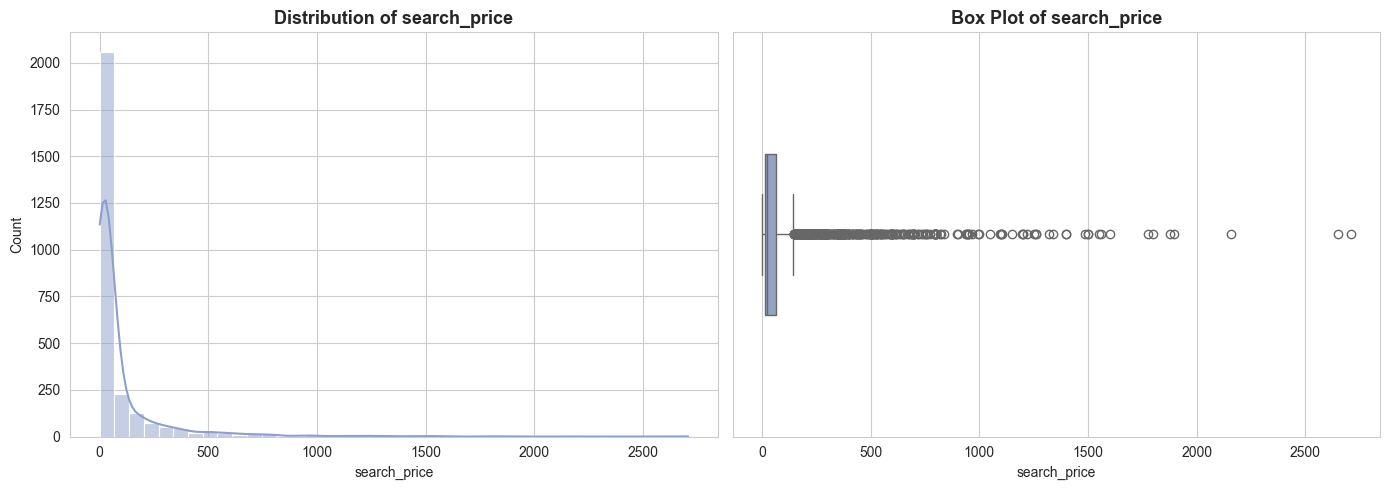

In [15]:
plot_numerical_distribution_and_boxplot(numeric_cols[2], 2)

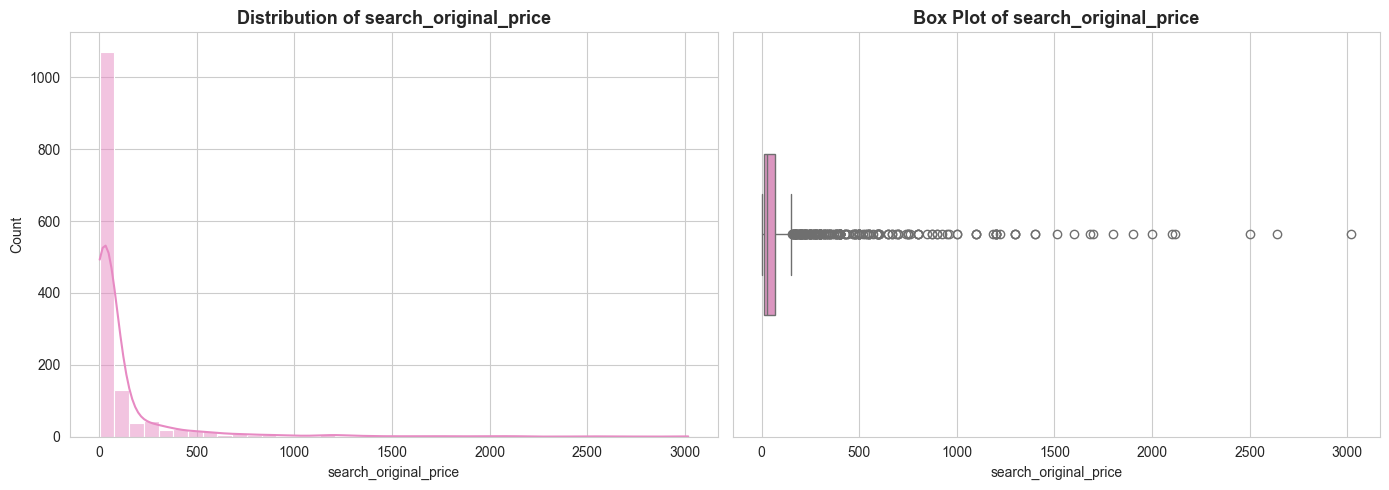

In [16]:
plot_numerical_distribution_and_boxplot(numeric_cols[3], 3)

### 2. Phân tích các đặc trưng Categorical

#### 2.1. Trích xuất đặc trưng

In [17]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"There are {len(categorical_cols)} categorical columns.")
print(categorical_cols)

There are 8 categorical columns.
['country_code', 'asin', 'title', 'link', 'image_url', 'search_currency', 'search_delivery_info', 'search_sales_volume']


#### 2.2. Giá trị phân phối

In [18]:
def plot_categorical_distribution(col_count, col_name, top_n=5):
    top_vals = col_count.nlargest(top_n).index
    top_counts = col_count.nlargest(top_n).values

    plt.figure(figsize=(12, 5))
    sns.barplot(x=top_counts, y=top_vals, hue=top_vals, palette="viridis", legend=False)
    plt.title(f'Most Frequent {col_name}', fontsize=15)
    plt.xlabel('Number of Appearances', fontsize=12)
    plt.ylabel(col_name, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Cột `search_sales_volume`

There are 30 unique values in search_sales_volume column.
Most frequent search_sales_volume values is: 10K+ bought in past month with 338 appearances.


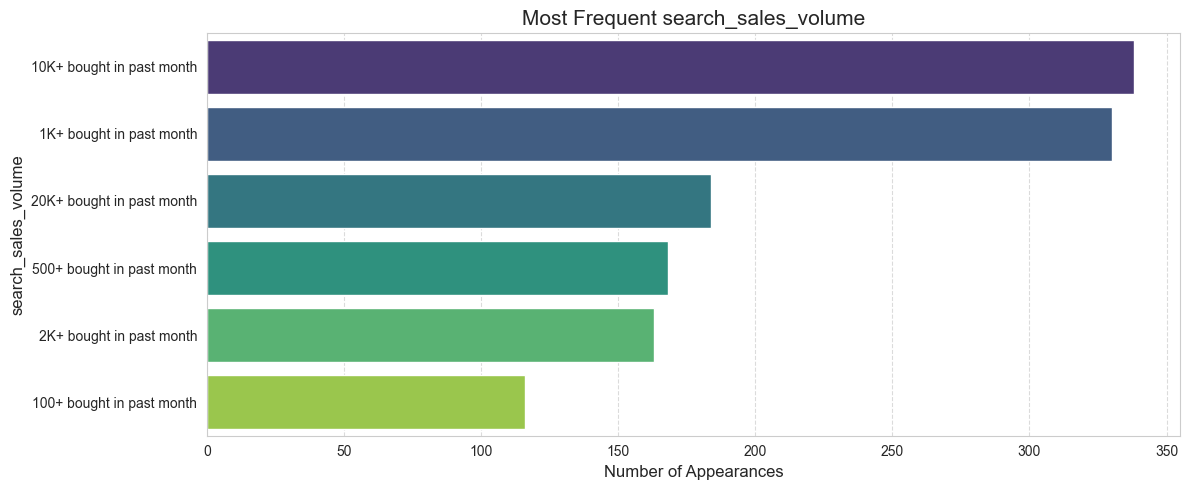

In [19]:

unique = df[categorical_cols[7]].nunique()
counts = df[categorical_cols[7]].value_counts()
print(f'There are {unique} unique values in {categorical_cols[7]} column.')
print(f'Most frequent {categorical_cols[7]} values is: {counts.idxmax()} with {counts.max()} appearances.')
plot_categorical_distribution(counts, categorical_cols[7], top_n = 6)

### 3. Phân tích các đặc trưng kiểu dữ liệu bool

#### 1. Trích xuất đặc trưng

In [20]:
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
print(f"There are {len(bool_cols)} boolean columns.")
print(bool_cols)

There are 5 boolean columns.
['search_is_best_seller', 'search_is_amazon_choice', 'search_is_prime', 'search_is_climate_friendly', 'search_has_variations']


In [21]:
df[bool_cols].describe()

,search_is_best_seller,search_is_amazon_choice,search_is_prime,search_is_climate_friendly,search_has_variations
count,2754,2754,2754,2754,2754
unique,1,1,2,2,2
top,True,False,False,False,False
freq,2754,2754,2630,2210,2024


| STT | Feature | Ý nghĩa | Phân phối | Đánh giá | Xử lý |
|-----|--------|--------|----------|---------|------|
| 1 | search_is_best_seller | Sản phẩm có thuộc danh sách Best Seller hay không | 100% True (không có False) | Không có biến thiên → không có ý nghĩa | Drop |
| 2 | search_is_amazon_choice | Sản phẩm có được gắn nhãn Amazon’s Choice hay không | 100% False (không có True) | Không có biến thiên → không có ý nghĩa | Drop |
| 3 | search_is_prime | Sản phẩm có hỗ trợ Amazon Prime hay không | Lệch mạnh về False (2630/2754) | Có ý nghĩa (liên quan trải nghiệm giao hàng) | Giữ + encode |
| 4 | search_is_climate_friendly | Sản phẩm có thân thiện môi trường hay không | Lệch mạnh về False | Có ý nghĩa (xu hướng tiêu dùng xanh) | Giữ + encode |
| 5 | search_has_variations | Sản phẩm có nhiều biến thể hay không | Lệch mạnh về False | Có ý nghĩa (đa dạng sản phẩm) | Giữ + encode |

## III. Quan hệ & Tương quan